| Dataset Size     | Industry Preference           |
| ---------------- | ----------------------------- |
| < 100k rows      | Train/Test + Cross Validation |
| 100k–1M rows     | Usually CV or Train/Val/Test  |
| Millions+ rows   | Train/Val/Test                |
| Deep Learning    | Train/Val/Test                |
| Expensive models | Train/Val/Test                |


Cross-validation is mainly used when data is limited or during hyperparameter tuning to get a reliable estimate of model performance. In industry, small and medium-sized tabular datasets often use Train-Test Split along with Cross Validation, whereas very large datasets and deep learning projects usually use Train-Validation-Test splits because cross-validation becomes computationally expensive.

# Data Understanding
1. Load the dataset and display all feature information.
2. Identify numerical and categorical features automatically.
3. Calculate memory usage and optimize it.
4. Detect duplicate records and justify whether to remove them.
5. Generate a complete data quality report.

In [1]:
import pandas as pd

data = pd.read_csv('emp.csv')

df = pd.DataFrame(data)

df.head()


,Employee_ID,Age,Gender,Department,Job_Role,Experience_Years,Education_Level,Certification_Count,AI_Training_Hours,Coding_Test_Score,...,Client_Rating,Bug_Fix_Count,Deployment_Success_Rate,Team_Size,Stress_Level,Work_Life_Balance,Job_Satisfaction,Attrition_Risk,Manager_Rating,Employee_Performance_Score
0,100001,50,Other,Finance,Support Engineer,25,Master,3,199,78,...,1.66,251,95.94,15,7,5,3,Low,5.00,62.54
1,100002,36,Other,IT,Cloud Engineer,32,Bachelor,8,164,40,...,3.54,72,80.29,19,3,8,8,Low,2.07,64.29
2,100003,29,Female,HR,Software Engineer,3,Bachelor,10,139,72,...,3.74,479,74.14,22,4,1,8,Low,4.08,59.40
3,100004,42,Male,IT,Software Engineer,8,PhD,11,284,77,...,1.74,131,81.49,6,2,8,7,Medium,1.22,69.55
4,100005,40,Female,Finance,DevOps Engineer,7,PhD,13,12,96,...,3.05,305,81.39,8,2,8,9,Low,2.97,73.09


In [2]:
# Identify numerical and categorical features
numerical_features = df.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)


Numerical Features: ['Employee_ID', 'Age', 'Experience_Years', 'Certification_Count', 'AI_Training_Hours', 'Coding_Test_Score', 'Communication_Score', 'Leadership_Score', 'Problem_Solving_Score', 'Innovation_Score', 'Attendance_Percentage', 'Remote_Work_Days', 'Overtime_Hours', 'Salary', 'Project_Count', 'Client_Rating', 'Bug_Fix_Count', 'Deployment_Success_Rate', 'Team_Size', 'Stress_Level', 'Work_Life_Balance', 'Job_Satisfaction', 'Manager_Rating', 'Employee_Performance_Score']
Categorical Features: ['Gender', 'Department', 'Job_Role', 'Education_Level', 'Promotion_Last_3Y', 'Attrition_Risk']


C:\Users\Dell\AppData\Local\Temp\ipykernel_4164\2511518853.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [3]:
# Calculate memory usage before optimization
print("=== MEMORY USAGE BEFORE OPTIMIZATION ===")
memory_before = df.memory_usage(deep=True).sum() / 1024**2
print(f"Total Memory Usage: {memory_before:.2f} MB")
print("\nMemory by Column:")
print(df.memory_usage(deep=True) / 1024)

# Optimize memory usage
df_optimized = df.copy()

# Convert int64 to int32
for col in numerical_features:
    if df_optimized[col].dtype == 'int64':
        df_optimized[col] = df_optimized[col].astype('int32')

# Convert float64 to float32
for col in numerical_features:
    if df_optimized[col].dtype == 'float64':
        df_optimized[col] = df_optimized[col].astype('float32')

# Convert object to category for categorical features
for col in categorical_features:
    df_optimized[col] = df_optimized[col].astype('category')

print("\n\n=== MEMORY USAGE AFTER OPTIMIZATION ===")
memory_after = df_optimized.memory_usage(deep=True).sum() / 1024**2
print(f"Total Memory Usage: {memory_after:.2f} MB")
print("\nMemory by Column:")
print(df_optimized.memory_usage(deep=True) / 1024)

# Calculate savings
savings = ((memory_before - memory_after) / memory_before) * 100
print(f"\n\nMemory Saved: {savings:.2f}%")
print(f"Size Reduction: {memory_before:.2f} MB → {memory_after:.2f} MB")

=== MEMORY USAGE BEFORE OPTIMIZATION ===
Total Memory Usage: 3.27 MB

Memory by Column:
Index                           0.128906
Employee_ID                    46.875000
Age                            46.875000
Gender                        363.207031
Department                    368.215820
Job_Role                      418.423828
Experience_Years               46.875000
Education_Level               367.123047
Certification_Count            46.875000
AI_Training_Hours              46.875000
Coding_Test_Score              46.875000
Communication_Score            46.875000
Leadership_Score               46.875000
Problem_Solving_Score          46.875000
Innovation_Score               46.875000
Attendance_Percentage          46.875000
Remote_Work_Days               46.875000
Overtime_Hours                 46.875000
Salary                         46.875000
Promotion_Last_3Y             348.687500
Project_Count                  46.875000
Client_Rating                  46.875000
Bug_Fix_Co

In [4]:
# Detect duplicate records
print(f"Total Records: {len(df)}")
print(f"Duplicate Rows (all columns identical): {df.duplicated().sum()}")
print(f"Duplicate Rows (excluding first occurrence): {df.duplicated(keep=False).sum()}")

# Check for duplicates on each subset
print("\n--- Duplicates by Column ---")
for col in df.columns:
    dup_count = df[col].duplicated().sum()
    print(f"{col}: {dup_count} duplicates")

# Display duplicate records if any
if df.duplicated().sum() > 0:
    print("\nDuplicate Records Found:")
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))

# Justification
dup_percentage = (df.duplicated().sum() / len(df)) * 100
print(f"Duplicate Percentage: {dup_percentage:.2f}%")

if df.duplicated().sum() == 0:
    print("✓ No duplicates found. No action needed.")
elif dup_percentage < 1:
    print("✓ Duplicates < 1%. Recommend: REMOVE to maintain data integrity")
else:
    print(f"⚠ Duplicates ≥ 1% ({dup_percentage:.2f}%). Action: INVESTIGATE before removing")

Total Records: 6000
Duplicate Rows (all columns identical): 0
Duplicate Rows (excluding first occurrence): 0

--- Duplicates by Column ---
Employee_ID: 0 duplicates
Age: 5962 duplicates
Gender: 5997 duplicates
Department: 5994 duplicates
Job_Role: 5985 duplicates
Experience_Years: 5965 duplicates
Education_Level: 5997 duplicates
Certification_Count: 5985 duplicates
AI_Training_Hours: 5700 duplicates
Coding_Test_Score: 5940 duplicates
Communication_Score: 5950 duplicates
Leadership_Score: 5940 duplicates
Problem_Solving_Score: 5940 duplicates
Innovation_Score: 5930 duplicates
Attendance_Percentage: 5969 duplicates
Remote_Work_Days: 5975 duplicates
Overtime_Hours: 5920 duplicates
Salary: 9 duplicates
Promotion_Last_3Y: 5998 duplicates
Project_Count: 5981 duplicates
Client_Rating: 5599 duplicates
Bug_Fix_Count: 5500 duplicates
Deployment_Success_Rate: 3418 duplicates
Team_Size: 5977 duplicates
Stress_Level: 5991 duplicates
Work_Life_Balance: 5991 duplicates
Job_Satisfaction: 5991 duplicat

# Exploratory Data Analysis
6. Identify skewed numerical features.
7. Find multicollinearity using VIF.
8. Detect highly correlated features (>0.90).
9. Visualize department-wise performance distributions.
10. Compare employee performance across education levels.

In [5]:
df.select_dtypes(include=['int64','float32'])

,Employee_ID,Age,Experience_Years,Certification_Count,AI_Training_Hours,Coding_Test_Score,Communication_Score,Leadership_Score,Problem_Solving_Score,Innovation_Score,Attendance_Percentage,Remote_Work_Days,Overtime_Hours,Salary,Project_Count,Bug_Fix_Count,Team_Size,Stress_Level,Work_Life_Balance,Job_Satisfaction
0,100001,50,25,3,199,78,93,48,59,37,75,12,40,669488,14,251,15,7,5,3
1,100002,36,32,8,164,40,73,57,84,91,88,17,74,534927,11,72,19,3,8,8
2,100003,29,3,10,139,72,56,87,84,48,71,17,48,1895516,12,479,22,4,1,8
3,100004,42,8,11,284,77,93,46,54,65,91,8,68,537600,13,131,6,2,8,7
4,100005,40,7,13,12,96,63,67,86,98,92,0,8,2090424,13,305,8,2,8,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,105996,48,0,5,167,86,73,87,92,44,83,18,9,511743,10,223,3,8,2,9
5996,105997,31,18,5,257,87,93,97,42,59,100,17,68,546432,7,107,6,2,9,8
5997,105998,53,20,0,237,45,61,96,69,73,91,3,65,2404532,13,204,6,1,8,6
5998,105999,47,21,1,44,57,76,61,58,38,98,12,40,2402191,9,173,14,2,5,6


In [6]:
# Identify skewed numerical features
from scipy.stats import skew
import numpy as np

print("\nSkewness Interpretation:")
print("  -1 to -0.5 or 0.5 to 1: Moderately skewed")
print("  < -1 or > 1: Highly skewed")
print("\n" + "="*50)

skewness_data = {}
for col in numerical_features:
    skewness = df[col].skew()          # this is skew function calculation
    skewness_data[col] = skewness
    
    # Categorize skewness
    if abs(skewness) > 1:
        category = "Highly Skewed"
    elif abs(skewness) > 0.5:
        category = "Moderately Skewed"
    else:
        category = "Approximately Symmetric"
    
    direction = "Right" if skewness > 0 else "Left" if skewness < 0 else "Symmetric"
    print(f"{col:20} | Skewness: {skewness:7.3f} | {category:20} | {direction} Skew")

# Summary
highly_skewed = [col for col, s in skewness_data.items() if abs(s) > 1]
print(f"Highly Skewed Features: {highly_skewed if highly_skewed else 'None'}")
print(f"Total Numerical Features: {len(numerical_features)}")


Skewness Interpretation:
  -1 to -0.5 or 0.5 to 1: Moderately skewed
  < -1 or > 1: Highly skewed

Employee_ID          | Skewness:   0.000 | Approximately Symmetric | Symmetric Skew
Age                  | Skewness:  -0.023 | Approximately Symmetric | Left Skew
Experience_Years     | Skewness:   0.019 | Approximately Symmetric | Right Skew
Certification_Count  | Skewness:  -0.004 | Approximately Symmetric | Left Skew
AI_Training_Hours    | Skewness:  -0.013 | Approximately Symmetric | Left Skew
Coding_Test_Score    | Skewness:  -0.014 | Approximately Symmetric | Left Skew
Communication_Score  | Skewness:   0.002 | Approximately Symmetric | Right Skew
Leadership_Score     | Skewness:   0.006 | Approximately Symmetric | Right Skew
Problem_Solving_Score | Skewness:   0.012 | Approximately Symmetric | Right Skew
Innovation_Score     | Skewness:  -0.000 | Approximately Symmetric | Left Skew
Attendance_Percentage | Skewness:   0.006 | Approximately Symmetric | Right Skew
Remote_Work_Days   

In [8]:
# Find multicollinearity using VIF
%pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Prepare data with numerical features only
X = df[numerical_features].copy()

# Handle missing values if any
X = X.fillna(X.mean())

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = numerical_features
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Sort by VIF in descending order
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("\nVIF Interpretation:")
print("  VIF = 1: No correlation")
print("  1 < VIF < 5: Moderate correlation (generally acceptable)")
print("  VIF >= 5: High multicollinearity (consider removing)")
print("  VIF >= 10: Severe multicollinearity (remove)")
print("\n" + "="*45)
print(vif_data.to_string(index=False))

# Summary
high_vif = vif_data[vif_data['VIF'] >= 5]
print(f"Features with VIF >= 5: {len(high_vif)}")
if len(high_vif) > 0:
    print("Features to consider removing:")
    for idx, row in high_vif.iterrows():
        print(f"  - {row['Feature']} (VIF: {row['VIF']:.2f})")
else:
    print("No severe multicollinearity detected.")

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 882.6 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/9.6 MB 1.0 MB/s eta 0:00:09
   ----- ---------------------------------- 1.3/9.6 MB 1.4 MB/s eta 0:00:07
   ------- -------------------------------- 1.8/9.6 MB 1.7 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.6 MB 1.7 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/9.6 MB 2.0 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.6 MB 2.0 MB/s eta 0:00:04
   ---------------- ----------------------- 3.9/9.6 MB 2.0 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.6 MB 2.0 MB/s eta 0:00:03
   -------------------- --------------

8. Detect highly correlated features (>0.90).

In [9]:
import numpy as np

numeric_df = df[numerical_features].copy()
corr_matrix = numeric_df.corr().abs()

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for i in range(len(upper_triangle.columns)):
    for j in range(i + 1, len(upper_triangle.columns)):
        col1 = upper_triangle.columns[i]
        col2 = upper_triangle.columns[j]
        corr_value = upper_triangle.iloc[i, j]
        if pd.notna(corr_value) and corr_value > 0.90:
            high_corr_pairs.append((col1, col2, round(float(corr_value), 3)))

print("Highly Correlated Feature Pairs (> 0.90):")
if high_corr_pairs:
    for col1, col2, corr_value in high_corr_pairs:
        print(f"{col1} - {col2}: {corr_value:.3f}")
else:
    print("No highly correlated feature pairs found.")


Highly Correlated Feature Pairs (> 0.90):
No highly correlated feature pairs found.


9. Visualize department-wise performance distributions.

<BarContainer object of 6000 artists>

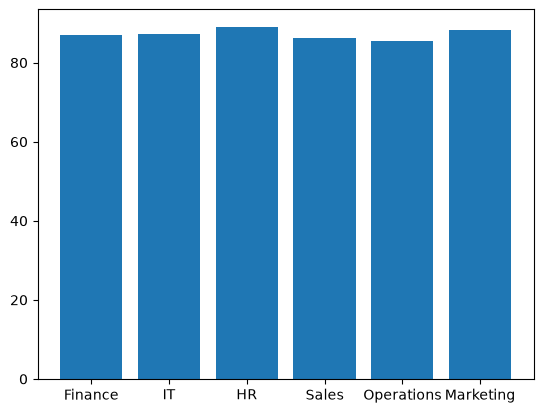

In [2]:
import matplotlib.pyplot as plt

plt.bar(df['Department'], df['Employee_Performance_Score'])

10. Compare employee performance across education levels.

<BarContainer object of 6000 artists>

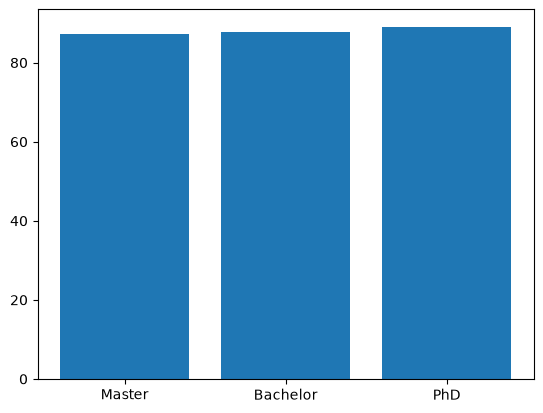

In [4]:
plt.bar(df['Education_Level'], df['Employee_Performance_Score'])

# FFeature Engineering

11. Create an Experience Level feature (Junior, Mid, Senior, Expert).

In [5]:
import numpy as np

conditions = [
    df['Experience_Years'] <= 3,
    df['Experience_Years'] <= 8,
    df['Experience_Years'] <= 15,
    df['Experience_Years'] > 15
]
choices = ['Junior', 'Mid', 'Senior', 'Expert']

df['Experience_Level'] = np.select(conditions, choices, default='Expert')

print(df[['Experience_Years', 'Experience_Level']].head())

   Experience_Years Experience_Level
0                25           Expert
1                32           Expert
2                 3           Junior
3                 8              Mid
4                 7              Mid


12. Create Salary Bands using quantiles.

In [7]:
q1, q2, q3 = df['Salary'].quantile([0.25, 0.5, 0.75])

bins = [0, q1, q2, q3, float('inf')]
labels = ['Low', 'Medium', 'High', 'Very High']

df['Salary_Band'] = pd.cut(df['Salary'], bins=bins, labels=labels, include_lowest=True)

print(df[['Salary', 'Salary_Band']].head(10))


    Salary Salary_Band
0   669488         Low
1   534927         Low
2  1895516        High
3   537600         Low
4  2090424   Very High
5  1022884      Medium
6   907666      Medium
7  1071775      Medium
8  2240305   Very High
9  1276761      Medium


13. Build a Performance Index from multiple scores.

In [8]:
score_columns = [
    'Coding_Test_Score',
    'Communication_Score',
    'Leadership_Score',
    'Problem_Solving_Score',
    'Innovation_Score',
    'Employee_Performance_Score'
]

# Average of the selected performance-related scores
# This gives a single composite feature for modeling

df['Performance_Index'] = df[score_columns].mean(axis=1)

print(df[['Coding_Test_Score', 'Communication_Score', 'Leadership_Score',
         'Problem_Solving_Score', 'Innovation_Score', 'Employee_Performance_Score',
         'Performance_Index']].head())

   Coding_Test_Score  Communication_Score  Leadership_Score  \
0                 78                   93                48   
1                 40                   73                57   
2                 72                   56                87   
3                 77                   93                46   
4                 96                   63                67   

   Problem_Solving_Score  Innovation_Score  Employee_Performance_Score  \
0                     59                37                       62.54   
1                     84                91                       64.29   
2                     84                48                       59.40   
3                     54                65                       69.55   
4                     86                98                       73.09   

   Performance_Index  
0          62.923333  
1          68.215000  
2          67.733333  
3          67.425000  
4          80.515000  


14. Generate Interaction Features between Coding Score and AI Training Hours

In [9]:
# Interaction feature: coding ability * AI training exposure
# This captures combined effect of technical skill and training intensity

df['Coding_AI_Interaction'] = df['Coding_Test_Score'] * df['AI_Training_Hours']

print(df[['Coding_Test_Score', 'AI_Training_Hours', 'Coding_AI_Interaction']].head())

   Coding_Test_Score  AI_Training_Hours  Coding_AI_Interaction
0                 78                199                  15522
1                 40                164                   6560
2                 72                139                  10008
3                 77                284                  21868
4                 96                 12                   1152


15. Apply One-Hot Encoding only where appropriate.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Select categorical columns that are suitable for one-hot encoding
# These columns contain non-numeric labels like 'Male', 'IT', 'Senior', etc.
# Machine learning models usually need numbers, so we convert them into binary columns.
categorical_cols = ['Gender', 'Department', 'Job_Role', 'Education_Level', 'Experience_Level', 'Salary_Band']

# ColumnTransformer is used to apply different preprocessing steps to different columns.
# Here, we only transform the categorical columns with OneHotEncoder,
# while the numeric columns are passed through unchanged.
# This is useful because we want to keep numeric features as they are and encode only the categorical ones.
preprocessor = ColumnTransformer(
    transformers=[
        # OneHotEncoder converts each category into its own binary column.
        # Example: 'Gender' -> 'Gender_Female', 'Gender_Male', 'Gender_Other'
        # This helps models understand categorical data without treating labels as ordered numbers.
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# fit_transform learns the categories from the data and transforms the selected columns into numbers.
# It also preserves the numeric columns (remainder='passthrough').
# This is preferred over manual encoding because it is cleaner, scalable, and reusable.
encoded_array = preprocessor.fit_transform(df[categorical_cols + [
    'Age', 'Experience_Years', 'Salary', 'Coding_Test_Score', 'AI_Training_Hours',
    'Communication_Score', 'Leadership_Score', 'Problem_Solving_Score',
    'Innovation_Score', 'Employee_Performance_Score', 'Performance_Index',
    'Coding_AI_Interaction'
]])

print('Encoded feature matrix shape:', encoded_array.shape)
print('Feature names:', preprocessor.get_feature_names_out())